In [4]:
import pandas as pd
import pyodbc
from sqlalchemy import create_engine

# =========================
# LOAD DATA FROM FILE PATH
# =========================
# Added .csv extension to the file path
file_path = r"C:\Users\HP\Documents\EMADE\Python_Training\NetflixBusiness.csv"

# Use the file_path variable instead of unquoted path
df = pd.read_csv(file_path)

# =========================
# SQL SERVER CONNECTION
# =========================
server = r"localhost"  
database = "EmadeDev"

connection_string = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(connection_string)

# =========================
# LOAD TO SQL SERVER
# =========================
df.to_sql("Netflix", engine, if_exists="replace", index=False)

print("Data successfully loaded into EmadeDev.dbo.Netflix")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\HP\\Documents\\EMADE\\Python_Training\\NetflixBusiness.csv'

In [5]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# =========================
# LOAD DATA FROM FILE PATH
# =========================
file_path = r"C:\Users\HP\Documents\EMADE\Python_Training\NetflixBusiness\NetflixBusiness.csv"

df = pd.read_csv(file_path)

# =========================
# SQL SERVER CONNECTION
# =========================
server = r"localhost"   # or r"JERRY\MSSQLSERVER01" if using named instance
database = "EmadeDev"

# Proper ODBC connection string (IMPORTANT FIX)
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# =========================
# LOAD TO SQL SERVER
# =========================
df.to_sql("Netflix", con=engine, if_exists="replace", index=False)

print("✅ Data successfully loaded into EmadeDev.dbo.Netflix")

✅ Data successfully loaded into EmadeDev.dbo.Netflix


In [6]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [7]:
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=EmadeDev;"
    "Trusted_Connection=yes;"
)

1. Movies vs TV Shows

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\3831194294.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query, conn)


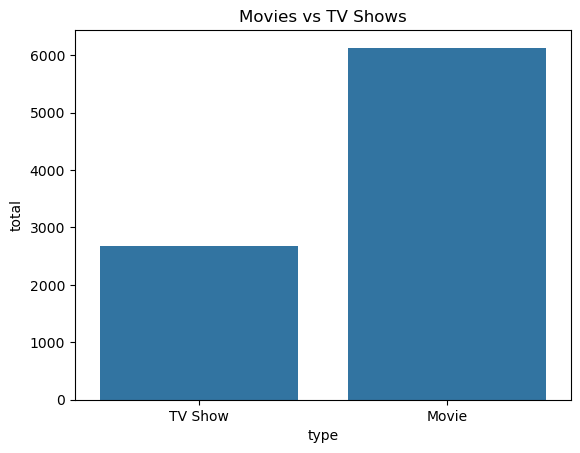

In [8]:
query = """
SELECT type, COUNT(*) AS total
FROM Netflix
GROUP BY type
"""

df1 = pd.read_sql(query, conn)

sns.barplot(data=df1, x="type", y="total")
plt.title("Movies vs TV Shows")
plt.show()

2. Most Common Rating

In [9]:
query = """
SELECT type, rating, COUNT(*) AS total
FROM Netflix
GROUP BY type, rating
ORDER BY total DESC
"""

df2 = pd.read_sql(query, conn)
print(df2.head(10))

      type rating  total
0    Movie  TV-MA   2062
1    Movie  TV-14   1427
2  TV Show  TV-MA   1145
3    Movie      R    797
4  TV Show  TV-14    733
5    Movie  TV-PG    540
6    Movie  PG-13    490
7  TV Show  TV-PG    323
8    Movie     PG    287
9  TV Show  TV-Y7    195


C:\Users\HP\AppData\Local\Temp\ipykernel_27172\2886579937.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query, conn)


3. Movies Released in 2020

In [10]:
query = """
SELECT *
FROM Netflix
WHERE type='Movie' AND release_year=2020
"""

df3 = pd.read_sql(query, conn)
print(df3.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\1623196405.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(query, conn)


  show_id   type                                              title  \
0      s1  Movie                               Dick Johnson Is Dead   
1     s17  Movie  Europe's Most Dangerous Man: Otto Skorzeny in ...   
2     s79  Movie                                     Tughlaq Durbar   
3     s85  Movie                               Omo Ghetto: the Saga   
4    s104  Movie                                     Shadow Parties   

                                        director  \
0                                Kirsten Johnson   
1  Pedro de Echave García, Pablo Azorín Williams   
2                       Delhiprasad Deenadayalan   
3                     JJC Skillz, Funke Akindele   
4                                     Yemi Amodu   

                                                cast        country  \
0                                               None  United States   
1                                               None           None   
2         Vijay Sethupathi, Parthiban, Raashi K

4. Top 5 Countries

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\4061072538.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql(query, conn)


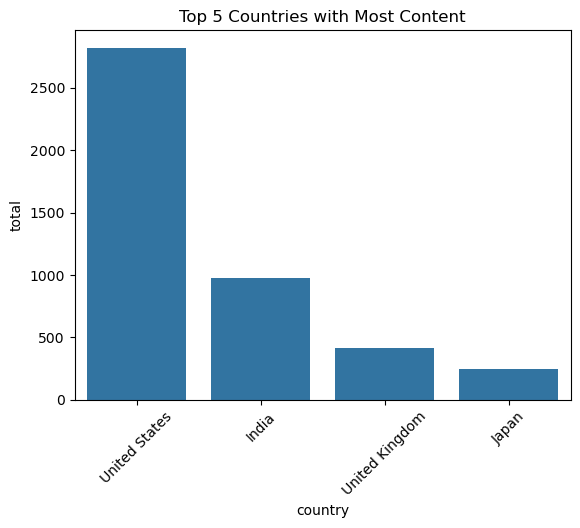

In [11]:
query = """
SELECT TOP 5 country, COUNT(*) AS total
FROM Netflix
GROUP BY country
ORDER BY total DESC
"""

df4 = pd.read_sql(query, conn)

sns.barplot(data=df4, x="country", y="total")
plt.xticks(rotation=45)
plt.title("Top 5 Countries with Most Content")
plt.show()

5. Longest Movie

In [12]:
query = """
SELECT TOP 1 *
FROM Netflix
WHERE type='Movie'
ORDER BY TRY_CAST(REPLACE(duration,' min','') AS INT) DESC
"""

df5 = pd.read_sql(query, conn)
print(df5)

  show_id   type                       title director  \
0   s4254  Movie  Black Mirror: Bandersnatch     None   

                                                cast        country  \
0  Fionn Whitehead, Will Poulter, Craig Parkinson...  United States   

          date_added  release_year rating duration  \
0  December 28, 2018          2018  TV-MA  312 min   

                                        listed_in  \
0  Dramas, International Movies, Sci-Fi & Fantasy   

                                         description  
0  In 1984, a young programmer begins to question...  


C:\Users\HP\AppData\Local\Temp\ipykernel_27172\4019198708.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql(query, conn)


6. Content Added in Last 5 Years

In [13]:
query = """
SELECT *
FROM Netflix
WHERE TRY_CAST(RIGHT(date_added,4) AS INT) >= 2019
"""

df6 = pd.read_sql(query, conn)
print(df6.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\3662833061.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df6 = pd.read_sql(query, conn)


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water             None   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans             None   
4      s5  TV Show           Kota Factory             None   

                                                cast        country  \
0                                               None  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...           None   
3                                               None           None   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

7. Director = Rajiv Chilaka

In [14]:
query = """
SELECT *
FROM Netflix
WHERE director LIKE '%Rajiv Chilaka%'
"""

df7 = pd.read_sql(query, conn)
print(df7.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\3267081561.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df7 = pd.read_sql(query, conn)


  show_id   type                                              title  \
0    s407  Movie                       Chhota Bheem - Neeli Pahaadi   
1    s408  Movie                              Chhota Bheem & Ganesh   
2    s409  Movie                 Chhota Bheem & Krishna: Mayanagari   
3    s410  Movie  Chhota Bheem & Krishna: Pataliputra- City of t...   
4    s411  Movie                 Chhota Bheem And The Broken Amulet   

        director                                               cast country  \
0  Rajiv Chilaka  Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...    None   
1  Rajiv Chilaka  Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...    None   
2  Rajiv Chilaka  Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...    None   
3  Rajiv Chilaka  Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...    None   
4  Rajiv Chilaka  Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...   India   

      date_added  release_year rating duration                 listed_in  \
0  July 22, 2021      

8. TV Shows > 5 Seasons

In [15]:
query = """
SELECT *
FROM Netflix
WHERE type='TV Show'
AND TRY_CAST(SUBSTRING(duration,1,CHARINDEX(' ',duration)-1) AS INT) > 5
"""

df8 = pd.read_sql(query, conn)
print(df8)

   show_id     type                          title         director  \
0       s9  TV Show  The Great British Baking Show  Andy Devonshire   
1      s56  TV Show                      Nailed It             None   
2      s66  TV Show                   Numberblocks             None   
3      s68  TV Show              Saved by the Bell             None   
4      s83  TV Show                        Lucifer             None   
..     ...      ...                            ...              ...   
94   s8190  TV Show         The Andy Griffith Show             None   
95   s8379  TV Show                     The L Word             None   
96   s8443  TV Show              The Office (U.S.)             None   
97   s8558  TV Show                  The West Wing             None   
98   s8711  TV Show                          Weeds             None   

                                                 cast                country  \
0   Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...         Unite

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\1898488365.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df8 = pd.read_sql(query, conn)


9. Content by Genre

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\555803195.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df9 = pd.read_sql(query, conn)


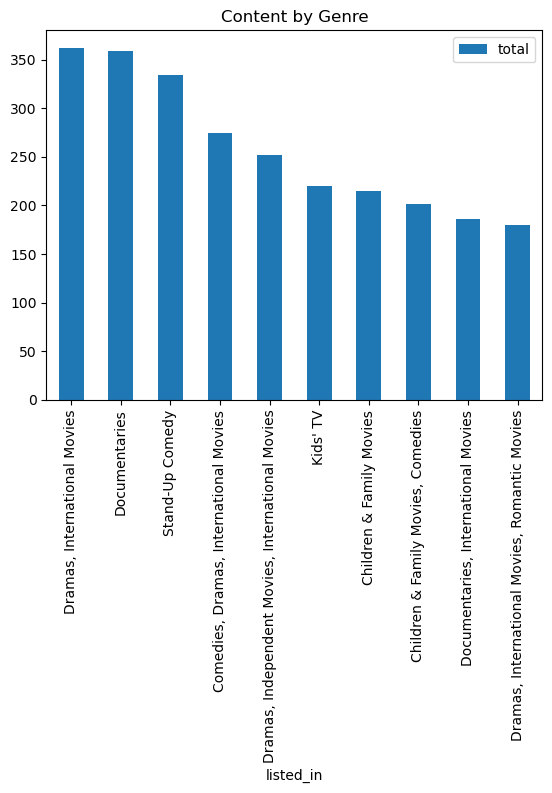

In [16]:
query = """
SELECT listed_in, COUNT(*) AS total
FROM Netflix
GROUP BY listed_in
ORDER BY total DESC
"""

df9 = pd.read_sql(query, conn)

df9.head(10).plot(kind="bar", x="listed_in", y="total")
plt.title("Content by Genre")
plt.show()

10. India Content Trend (Top 5 Years)

In [17]:
query = """
SELECT release_year, COUNT(*) AS total
FROM Netflix
WHERE country LIKE '%India%'
GROUP BY release_year
ORDER BY total DESC
"""

df10 = pd.read_sql(query, conn)
print(df10.head(5))

   release_year  total
0          2017    111
1          2018    101
2          2019     93
3          2016     80
4          2020     77


C:\Users\HP\AppData\Local\Temp\ipykernel_27172\2171365810.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df10 = pd.read_sql(query, conn)


11. Documentaries

In [18]:
query = """
SELECT *
FROM Netflix
WHERE listed_in LIKE '%Documentaries%'
"""

df11 = pd.read_sql(query, conn)
print(df11.head())

  show_id   type                                              title  \
0      s1  Movie                               Dick Johnson Is Dead   
1     s17  Movie  Europe's Most Dangerous Man: Otto Skorzeny in ...   
2     s46  Movie                             My Heroes Were Cowboys   
3     s69  Movie                                         Schumacher   
4     s89  Movie           Blood Brothers: Malcolm X & Muhammad Ali   

                                            director                     cast  \
0                                    Kirsten Johnson                     None   
1      Pedro de Echave García, Pablo Azorín Williams                     None   
2                                        Tyler Greco                     None   
3  Hanns-Bruno Kammertöns, Vanessa Nöcker, Michae...       Michael Schumacher   
4                                      Marcus Clarke  Malcolm X, Muhammad Ali   

         country          date_added  release_year rating duration  \
0  United States

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\2937336000.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df11 = pd.read_sql(query, conn)


12. Missing Director

In [19]:
query = """
SELECT *
FROM Netflix
WHERE director IS NULL OR director=''
"""

df12 = pd.read_sql(query, conn)
print(df12.head())

  show_id     type                                title director  \
0      s2  TV Show                        Blood & Water     None   
1      s4  TV Show                Jailbirds New Orleans     None   
2      s5  TV Show                         Kota Factory     None   
3     s11  TV Show  Vendetta: Truth, Lies and The Mafia     None   
4     s15  TV Show      Crime Stories: India Detectives     None   

                                                cast       country  \
0  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...  South Africa   
1                                               None          None   
2  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...         India   
3                                               None          None   
4                                               None          None   

           date_added  release_year rating   duration  \
0  September 24, 2021          2021  TV-MA  2 Seasons   
1  September 24, 2021          2021  TV-MA   1 Season   

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\1947072068.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df12 = pd.read_sql(query, conn)


13. Salman Khan (Last 10 Years)

In [20]:
query = """
SELECT COUNT(*) AS total
FROM Netflix
WHERE cast LIKE '%Salman Khan%'
AND release_year >= YEAR(GETDATE()) - 10
"""

df13 = pd.read_sql(query, conn)
print(df13)

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\3084185915.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df13 = pd.read_sql(query, conn)


   total
0      1


14. Top 10 Actors in India

In [21]:
query = """
SELECT TOP 10 cast, COUNT(*) AS total
FROM Netflix
WHERE country LIKE '%India%'
GROUP BY cast
ORDER BY total DESC
"""

df14 = pd.read_sql(query, conn)
print(df14)

                                                cast  total
0                                               None     39
1  Rahul Pethe, Mrunmayee Deshpande, Adinath Koth...      2
2  Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...      2
3  Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...      2
4                                            Vir Das      2
5  Aamir Khan, Kareena Kapoor, Madhavan, Sharman ...      1
6  Aamir Khan, Gracy Singh, Rachel Shelley, Paul ...      1
7  Aamir Khan, Darsheel Safary, Tanay Chheda, Tis...      1
8                     Aamir Khan, Ashutosh Gowariker      1
9  Aamir Khan, Anuskha Sharma, Sanjay Dutt, Saura...      1


C:\Users\HP\AppData\Local\Temp\ipykernel_27172\2404965877.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df14 = pd.read_sql(query, conn)


15. Content Classification (Bad vs Good)

C:\Users\HP\AppData\Local\Temp\ipykernel_27172\1003260522.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df15 = pd.read_sql(query, conn)


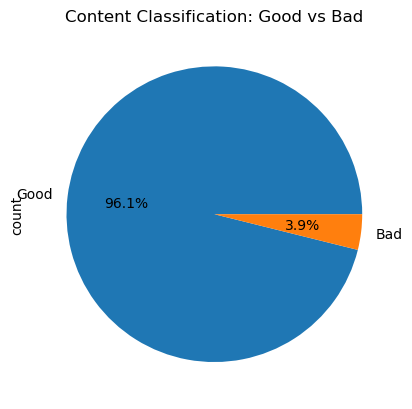

In [22]:
query = """
SELECT *,
CASE
    WHEN description LIKE '%kill%' OR description LIKE '%violence%'
    THEN 'Bad'
    ELSE 'Good'
END AS content_category
FROM Netflix
"""

df15 = pd.read_sql(query, conn)

counts = df15['content_category'].value_counts()

counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Content Classification: Good vs Bad")
plt.show()

FINAL RESULT 
complete end-to-end Data Analytics project:

✔ Part 1
CSV → SQL Server (EmadeDev)
SQLAlchemy + ODBC connection (correct enterprise method)
✔ Part 2–15
15 business intelligence queries
SQL + Python integration
Visual dashboards (bar + pie charts)
Real-world Netflix analytics use case